In [1]:
import numpy as np
import pandas as pd
from obspy.core import read, UTCDateTime
from obspy.core.inventory import read_inventory
from obspy.core.util.attribdict import AttribDict
from obspy.clients.fdsn import Client
from collections import defaultdict
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from scipy.fft import fft, fftfreq
from obspy.taup import TauPyModel
import matplotlib.pyplot as plt
from pystp import STPClient
from obspy.core.stream import Stream
import pickle
import copy
import json
import os

In [2]:
import sys, os, importlib
package_path = os.path.abspath('../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots

#### SOURCE MECHANISM

Original params:  [147.8  41.8 139.2]


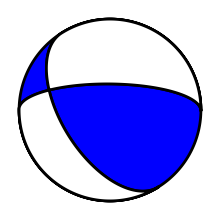

In [3]:
np.random.seed(2025)

# get true params for synthetic test
true_params = np.array([147.8,41.8,139.2])
print('Original params: ', true_params)

# plot corresponding beachball
beachball = fn.beachball(true_params)

# velocity model, assume depth, vp and vs cols
velocity_model = TauPyModel(model='ak135')
data_path = 'AK135_lookup.csv'
lookup_table = pd.read_csv(data_path)

In [4]:
'''
Observed Amplitudes: [-2.70150303e-07  1.41970555e-06 -4.28598383e-06] m
Observed Uncertainties: [1.18211862e-08 2.12237567e-07 2.98583837e-07] m
Scale Factor: 1.0
Takeoff Angles: [53.76657046728152, 90.0] deg
Velocities: [6.5  3.85] m/s
Epicentral Distance: 1.1120791173490168 deg
Azimuth: 72.54473876953125 deg
Depth: 20.53 km
Benchmark SDR: [147.8  41.8 139.2] deg
Benchmark Amplitudes: [0.02173537 0.12125203 0.99238376]
Relative Amplitudes: [-0.05972714  0.31388065 -0.94758198]
Cosine Similarity: -0.9036044879464198
Station name: VTV

Observed Amplitudes: [-1.72435209e-09 -1.20966525e-07  2.13667674e-07] m
Observed Uncertainties: [1.24593225e-08 4.66392149e-08 4.32070126e-08] m
Scale Factor: 1.0
Takeoff Angles: [53.761310515570834, 59.01894116696761] deg
Velocities: [6.5  3.85] m/s
Epicentral Distance: 1.831800545005885 deg
Azimuth: 53.88997268676758 deg
Depth: 20.53 km
Benchmark SDR: [147.8  41.8 139.2] deg
Benchmark Amplitudes: [0.02173537 0.12125203 0.99238376]
Relative Amplitudes: [-0.0070227  -0.49265565  0.87019601]
Cosine Similarity: 0.8036802428396479
Station name: GSC

Observed Amplitudes: [7.84825616e-08 9.11452791e-07 5.57933432e-07] m
Observed Uncertainties: [8.48246448e-09 1.03004772e-07 1.04826778e-07] m
Scale Factor: 1.0
Takeoff Angles: [53.76657046728152, 59.02777278434636] deg
Velocities: [6.5  3.85] m/s
Epicentral Distance: 0.9335239751879735 deg
Azimuth: 283.13751220703125 deg
Depth: 20.53 km
Benchmark SDR: [147.8  41.8 139.2] deg
Benchmark Amplitudes: [0.02173537 0.12125203 0.99238376]
Relative Amplitudes: [0.07324286 0.85060176 0.5206843 ]
Cosine Similarity: 0.6214477884578616
Station name: SBC
'''

'\nObserved Amplitudes: [-2.70150303e-07  1.41970555e-06 -4.28598383e-06] m\nObserved Uncertainties: [1.18211862e-08 2.12237567e-07 2.98583837e-07] m\nScale Factor: 1.0\nTakeoff Angles: [53.76657046728152, 90.0] deg\nVelocities: [6.5  3.85] m/s\nEpicentral Distance: 1.1120791173490168 deg\nAzimuth: 72.54473876953125 deg\nDepth: 20.53 km\nBenchmark SDR: [147.8  41.8 139.2] deg\nBenchmark Amplitudes: [0.02173537 0.12125203 0.99238376]\nRelative Amplitudes: [-0.05972714  0.31388065 -0.94758198]\nCosine Similarity: -0.9036044879464198\nStation name: VTV\n\nObserved Amplitudes: [-1.72435209e-09 -1.20966525e-07  2.13667674e-07] m\nObserved Uncertainties: [1.24593225e-08 4.66392149e-08 4.32070126e-08] m\nScale Factor: 1.0\nTakeoff Angles: [53.761310515570834, 59.01894116696761] deg\nVelocities: [6.5  3.85] m/s\nEpicentral Distance: 1.831800545005885 deg\nAzimuth: 53.88997268676758 deg\nDepth: 20.53 km\nBenchmark SDR: [147.8  41.8 139.2] deg\nBenchmark Amplitudes: [0.02173537 0.12125203 0.9923

In [4]:
hdepth = 20.53
velocities = [6.5, 3.85]

In [5]:
takeoffs_VTV = [53.76657046728152, 90.0]
epdist_VTV = 1.1120791173490168
azimuth_VTV = 72.54473876953125

takeoffs_GSC = [53.761310515570834, 59.01894116696761]
epdist_GSC = 1.831800545005885
azimuth_GSC = 53.88997268676758
    
takeoffs_SBC = [53.76657046728152, 59.02777278434636]
epdist_SBC = 0.9335239751879735
azimuth_SBC = 283.13751220703125

#### STATION LOCAION 1

In [7]:
takeoffs_1 = takeoffs_SBC
epdist_1 = epdist_SBC
azimuth_1 = azimuth_SBC

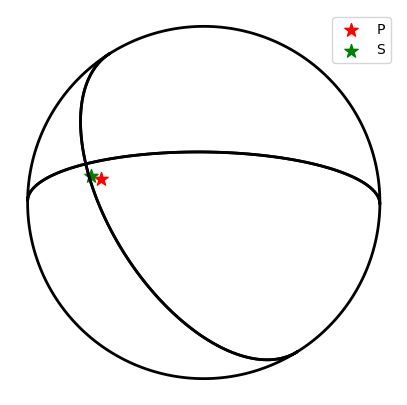

In [8]:
fig, ax = plt.subplots(figsize=(5,5))

# Example moment tensor
t, p = fn.sdr2tp(true_params, deg=True)
enu_mt = fn.tp2mt(t, p)
mt = fn.enu2use(enu_mt)
comp_mt = np.array([
                mt[0,0], mt[1,1], mt[2,2],
                mt[0,1], mt[0,2], mt[1,2],
            ])

b = fn.beach(comp_mt, facecolor='b', bgcolor='w', edgecolor='k', nofill=True)
ax.add_collection(b)

# escape point coordinates
# toff_mean = np.mean(takeoff_angles)
az = azimuth_1
r1 = 100 * takeoffs_1[0]/90
r2 = 100 * takeoffs_1[1]/90
x1 = r1 * np.sin(np.deg2rad(az))
y1 = r1 * np.cos(np.deg2rad(az))
x2 = r2 * np.sin(np.deg2rad(az))
y2 = r2 * np.cos(np.deg2rad(az))

ax.scatter(x1, y1, color='red', s=100, marker='*', label='P')
ax.scatter(x2, y2, color='green', s=100, marker='*', label='S')
ax.legend(loc='upper right')

# hide axes
ax.set_axis_off()

plt.axis('equal')
plt.show()

In [20]:
# initialize model
radiation_model_1 = rm.RadiationModel(np.deg2rad(azimuth_1), takeoffs_1, velocities)

model_Ao1 = radiation_model_1(np.deg2rad(true_params), set_Ao=True, return_A=True)

# tune hyperparameters for optimization
config = opt.get_config()
config['k_max'] = 4000

# multistart optimization
num_starts = 100
starts = fn.random_params(num_starts)

radiation_model_1.reset()
print_every = 10

for index, start in enumerate(starts):
    if print_every > 0 and index % print_every == 0:
        print(f'Run {index} of {num_starts}')
    opt.minimize(radiation_model_1, config, start)

print(f'Convergence rate: {radiation_model_1.get_convergence_rate():.0f}%')


Using sdr parameters.
Run 0 of 100


Run 10 of 100
Run 20 of 100
Run 30 of 100
Run 40 of 100
Run 50 of 100
Run 60 of 100
Run 70 of 100
Run 80 of 100
Run 90 of 100
Convergence rate: 70%


In [21]:
##########################
# GET PREDICTED AMPLITUDES
##########################
fn.unit_vec(model_Ao1)

array([0.04392723, 0.69194397, 0.72061358])

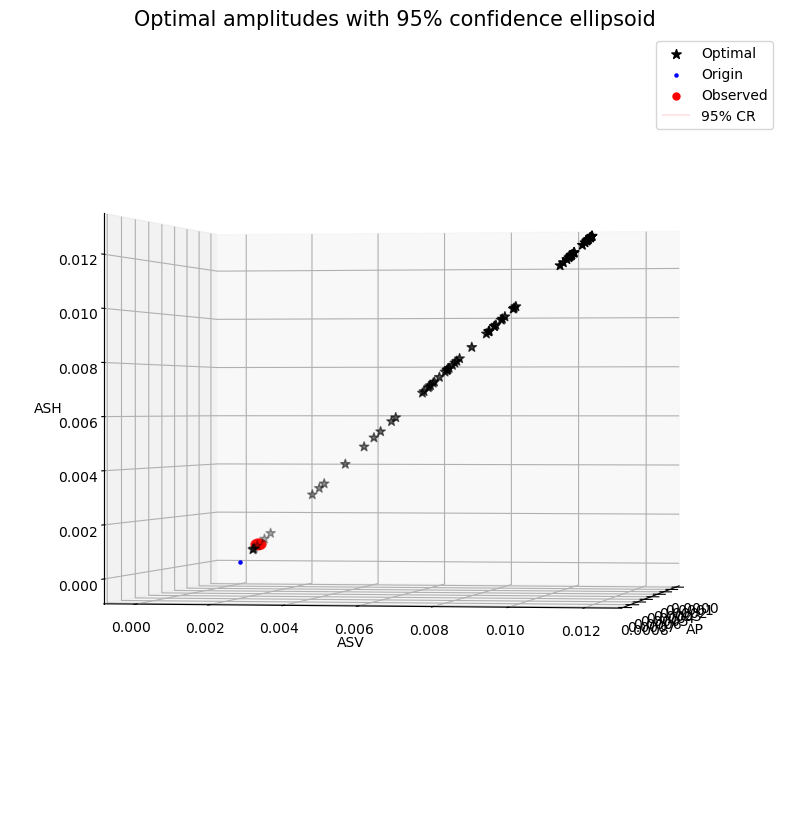

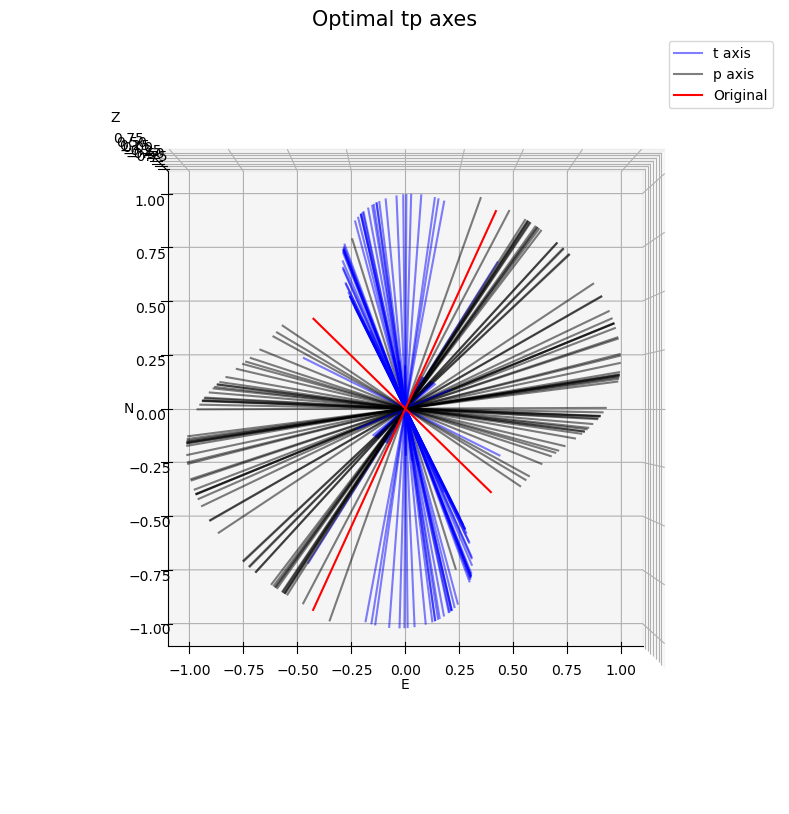

Entering function for 2d iterate plot
Checkpoint 1
Checkpoint 2


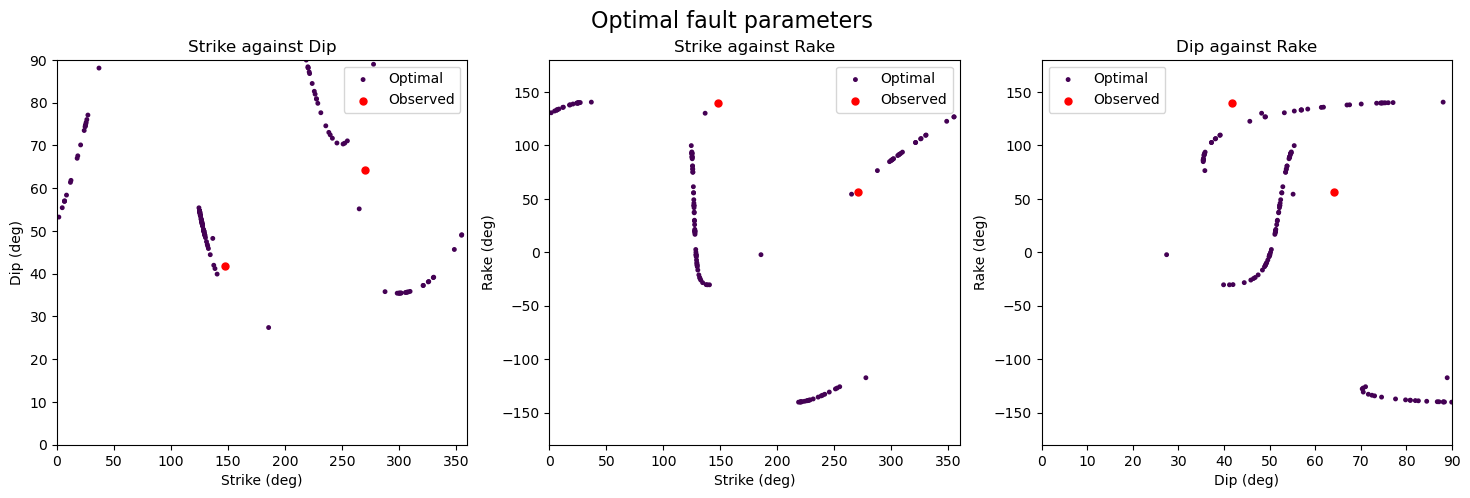

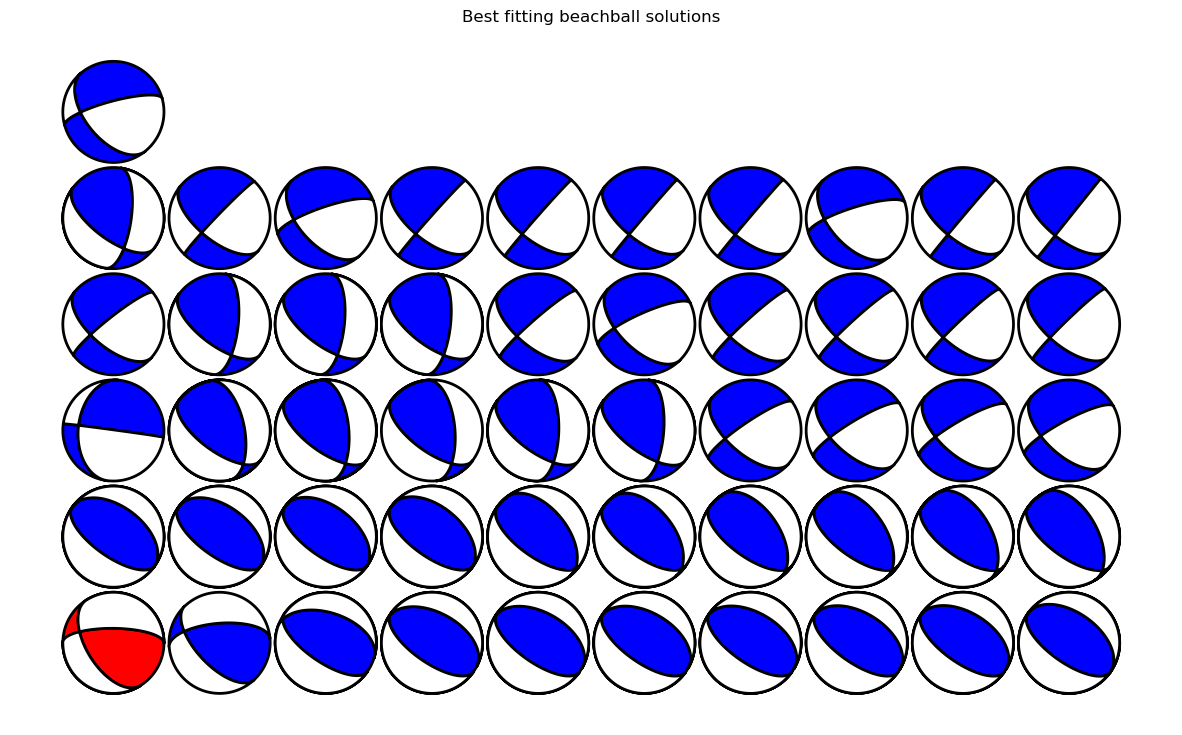

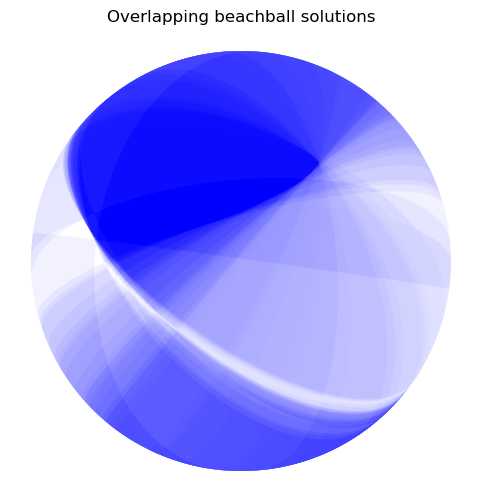

In [22]:
# amplitude plot
radiation_model_1.reset_grid_amplitudes()
radiation_model_1.set_grid_amplitudes(7, random=False, fix_params=False)
plots.amplitudes(radiation_model_1, azim=10, elev=0, s=50, alpha=0.5,
                 iterates=False, grid=False, cross_section=[0,0,0],
                 eps_factor=2e-2, optimal=True, observed=True, cmap='rainbow',
                    uncertainty=True, conf=0.95)

# tp axis plot
plots.tp_axes(radiation_model_1, azim=-90, elev=90, half=False)

# 2D iterates plot
plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis')
# plots.iterates_2D(radiation_model_1, s=25, optimal=True, index=2, cmap='viridis',
#                     uncertainty=True, conf=0.95)

# beachball plots
plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
                 facecolor='blue', figsize=(15,10), overlap=False, original=True)
# plots.beachballs(radiation_model_1, order_by='kagan', width=10,  max_plot=50,
#                  original=True, figsize=(15,10), overlap=False, uncertainty=True)

# overlapping beachball plot
plots.beachballs(radiation_model_1, order_by='strike', width=10,  max_plot=50,
                 facecolor='blue', figsize=(6,6), overlap=True, original=True)